<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/dimensionality_reduction_using_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.2424 - val_loss: 0.1655
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1496 - val_loss: 0.1368
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1314 - val_loss: 0.1244
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1217 - val_loss: 0.1188
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1162 - val_loss: 0.1123
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1122 - val_loss: 0.1088
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1086 - val_loss: 0.1055
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1054 - val_loss: 0.1028
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1029 - val_loss: 0.1016
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1011 - val_loss: 0.0991
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


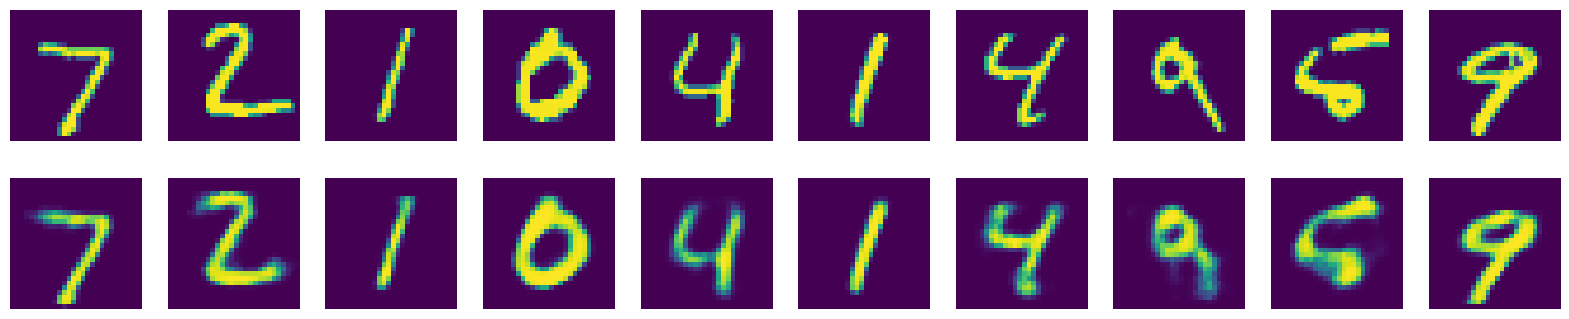

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST
(x_train,_),(x_test,_) = tf.keras.datasets.mnist.load_data()

# Normalize and flatten
x_train = x_train.reshape(-1,784)/255.0
x_test = x_test.reshape(-1,784)/255.0

# Encoder
input_img = layers.Input(shape=(784,))
x = layers.Dense(128,activation='relu')(input_img)
x = layers.Dense(64,activation='relu')(x)
encoded = layers.Dense(32,activation='relu')(x)

# Decoder
x = layers.Dense(64,activation='relu')(encoded)
x = layers.Dense(128,activation='relu')(x)
decoded = layers.Dense(784,activation='sigmoid')(x)

# Autoencoder
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(x_train,x_train,epochs=10,batch_size=256,validation_data=(x_test,x_test))

# Reconstruct images
decoded_imgs = autoencoder.predict(x_test)

# Plot results
n=10
plt.figure(figsize=(20,4))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28)); plt.axis('off')

    plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28)); plt.axis('off')

plt.show()